In [1]:
import glob
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt


import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
print("Version de TensorFlow :", tf.__version__)
from tensorflow.keras import layers, models, Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

Version de TensorFlow : 2.13.1


In [2]:
PATH_DATA = "../data" 

def generer_mel_spectrogramme(chemin_fichier, target_shape=(128, 128)):
    try:
        y, sr = librosa.load(chemin_fichier, duration=3.0, sr=22050)
        if len(y) == 0: return None
        
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=target_shape[0], fmax=8000)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Ajustement à une taille fixe (128x128)
        if mel_spec_db.shape[1] < target_shape[1]:
            pad_width = target_shape[1] - mel_spec_db.shape[1]
            mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, pad_width)), mode='constant')
        else:
            mel_spec_db = mel_spec_db[:, :target_shape[1]]
            
        # Normalisation Min-Max
        mel_min, mel_max = mel_spec_db.min(), mel_spec_db.max()
        if mel_max - mel_min > 0:
            mel_spec_db = (mel_spec_db - mel_min) / (mel_max - mel_min)
            
        return np.expand_dims(mel_spec_db, axis=-1)
    except:
        return None

In [3]:
dictionnaire_synonymes = {
    'sax': 'saxophone', 'tru': 'trumpet', 'vio': 'violin',
    'gac': 'guitar', 'gel': 'guitar', 'guitar': 'guitar',
    'pia': 'piano', 'flu': 'flute', 'cla': 'clarinet', 'voi': 'voice'
}

fichiers_audio = []
for ext in ('/**/*.wav', '/**/*.mp3'):
    fichiers_audio.extend(glob.glob(PATH_DATA + ext, recursive=True))

In [4]:
liste_matrices = []
liste_labels = []

# On limite à 1000 exemples pour que l'entraînement sur ton CPU soit rapide pour la démo
print(f"Transformation de {len(fichiers_audio)} fichiers audio...")
for chemin in fichiers_audio:
    chemin_norm = os.path.normpath(chemin).replace('\\', '/')
    inst = chemin_norm.split('/')[-2]
    clean_label = dictionnaire_synonymes.get(inst, inst)
    
    img_matrix = generer_mel_spectrogramme(chemin_norm)
    if img_matrix is not None:
        liste_matrices.append(img_matrix)
        liste_labels.append(clean_label)

# Conversion finale en tableaux NumPy après la boucle
X_deep = np.array(liste_matrices)
labels_cible = np.array(liste_labels)

classes_uniques, y_encoded = np.unique(labels_cible, return_inverse=True)
num_classes = len(classes_uniques)

X_train, X_temp, y_train, y_temp = train_test_split(X_deep, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Données prêtes ! Taille de l'ensemble d'entraînement : {X_train.shape}")
print(f"Nombre de classes détectées : {num_classes}")
print(f"Liste des instruments : {classes_uniques}")

Transformation de 23262 fichiers audio...


c:\Users\Administrateur\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1728
  warnings.warn(
C:\Users\Administrateur\AppData\Local\Temp\ipykernel_12432\1573108730.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(chemin_fichier, duration=3.0, sr=22050)
c:\Users\Administrateur\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Données prêtes ! Taille de l'ensemble d'entraînement : (16282, 128, 128, 1)
Nombre de classes détectées : 27
Liste des instruments : ['IRTestingData-Part2' 'Part1' 'Part3' 'banjo' 'bass clarinet' 'bassoon'
 'cel' 'cello' 'clarinet' 'contrabassoon' 'cor anglais' 'double bass'
 'flute' 'french horn' 'guitar' 'mandolin' 'oboe' 'org' 'percussion'
 'piano' 'saxophone' 'trombone' 'trumpet' 'tuba' 'viola' 'violin' 'voice']


In [5]:
model_cnn = models.Sequential([
    # 1. Première couche de Convolution pour capter les formes de base (bords, lignes de fréquences)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),
    layers.MaxPooling2D((2, 2)), # Réduit la taille pour ne garder que le plus important
    
    # 2. Deuxième couche pour des motifs plus complexes (les timbres de voix ou d'instruments)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # Sécurité contre le sur-apprentissage (overfitting)
    
    # 3. Aplatissement des matrices en un seul vecteur
    layers.Flatten(),
    
    # 4. Couches denses classiques pour la prise de décision finale
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax') # Donne une probabilité pour chaque classe
])

# Compilation avec l'optimiseur standard et la fonction de perte adaptée
model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Affichage du résumé de l'architecture pour le jury
model_cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 dropout (Dropout)           (None, 30, 30, 64)        0         
                                                                 
 flatten (Flatten)           (None, 57600)             0

🔥 Lancement de l'entraînement du CNN...
Epoch 1/30
509/509 [==============================] - 80s 157ms/step - loss: 2.6191 - accuracy: 0.2063 - val_loss: 1.9209 - val_accuracy: 0.4652
Epoch 2/30
509/509 [==============================] - 82s 160ms/step - loss: 1.9960 - accuracy: 0.3606 - val_loss: 1.4848 - val_accuracy: 0.5526
Epoch 3/30
509/509 [==============================] - 80s 157ms/step - loss: 1.7264 - accuracy: 0.4380 - val_loss: 1.2912 - val_accuracy: 0.5967
Epoch 4/30
509/509 [==============================] - 82s 162ms/step - loss: 1.5640 - accuracy: 0.4875 - val_loss: 1.1915 - val_accuracy: 0.6331
Epoch 5/30
509/509 [==============================] - 84s 166ms/step - loss: 1.4594 - accuracy: 0.5152 - val_loss: 1.1150 - val_accuracy: 0.6452
Epoch 6/30
509/509 [==============================] - 87s 170ms/step - loss: 1.3771 - accuracy: 0.5431 - val_loss: 1.0831 - val_accuracy: 0.6523
Epoch 7/30
509/509 [==============================] - 93s 182ms/step - loss: 1.2973 - accu

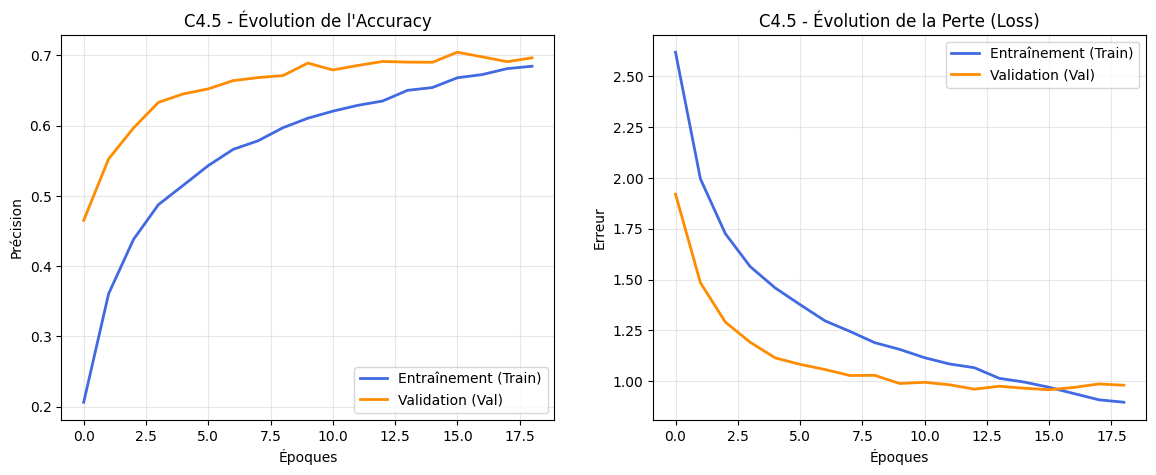

In [6]:
callback_early_stopping = EarlyStopping(
    monitor='val_loss',     # Il surveille l'erreur sur les données de validation
    patience=3,             # Si pendant 3 époques d'affilée la val_loss ne s'améliore pas, il coupe !
    restore_best_weights=True # Très important : il recharge les meilleurs poids du modèle (pas ceux du moment où il a planté)
)

print("🔥 Lancement de l'entraînement du CNN...")
# On part sur 8 époques, parfait pour une démo rapide et fluide sur ton CPU
history = model_cnn.fit(
    X_train, y_train, 
    validation_data=(X_val, y_val), 
    epochs=30, 
    batch_size=32,
    callbacks=[callback_early_stopping]
)

# --- GRAPHIQUES DES INDICATEURS DE PERFORMANCE ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphique de l'Accuracy
ax1.plot(history.history['accuracy'], label='Entraînement (Train)', color='royalblue', lw=2)
ax1.plot(history.history['val_accuracy'], label='Validation (Val)', color='darkorange', lw=2)
ax1.set_title("C4.5 - Évolution de l'Accuracy")
ax1.set_xlabel("Époques")
ax1.set_ylabel("Précision")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphique de la Perte (Loss)
ax2.plot(history.history['loss'], label='Entraînement (Train)', color='royalblue', lw=2)
ax2.plot(history.history['val_loss'], label='Validation (Val)', color='darkorange', lw=2)
ax2.set_title("C4.5 - Évolution de la Perte (Loss)")
ax2.set_xlabel("Époques")
ax2.set_ylabel("Erreur")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

In [9]:
score_val = model_cnn.evaluate(X_val, y_val, verbose=0)

print("--- RÉSULTATS RETENUS POUR L'INDUSTRIALISATION ---")
print(f"Meilleure Précision (Validation Accuracy) : {score_val[1]*100:.2f} %")
print(f"Perte Optimale (Validation Loss)       : {score_val[0]:.4f}")

--- RÉSULTATS RETENUS POUR L'INDUSTRIALISATION ---
Meilleure Précision (Validation Accuracy) : 70.45 %
Perte Optimale (Validation Loss)       : 0.9582


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. LE GÉNÉRATEUR : Sa mission est de créer un faux spectrogramme (128x128x1) à partir d'un bruit aléatoire
generateur = models.Sequential([
    # Entrée : un vecteur de bruit aléatoire de taille 100
    layers.Dense(32 * 32 * 64, input_dim=100),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha=0.2),
    layers.Reshape((32, 32, 64)),
    
    # On agrandit la matrice pour passer de 32x32 à 64x64
    layers.Conv2DTranspose(32, (4, 4), strides=(2, 2), padding='same'),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha=0.2),
    
    # On agrandit à nouveau pour atteindre la taille finale de nos spectrogrammes : 128x128 avec 1 canal
    layers.Conv2DTranspose(1, (4, 4), strides=(2, 2), padding='same', activation='tanh')
], name="Generateur_Audio")

# 2. LE DISCRIMINATEUR : Sa mission est de jouer le rôle du flic (détecter si le spectrogramme est vrai ou faux)
discriminateur = models.Sequential([
    layers.Conv2D(64, (4, 4), strides=(2, 2), padding='same', input_shape=(128, 128, 1)),
    layers.LeakyReLU(alpha=0.2),
    layers.Dropout(0.3),
    
    layers.Conv2D(128, (4, 4), strides=(2, 2), padding='same'),
    layers.LeakyReLU(alpha=0.2),
    layers.Dropout(0.3),
    
    layers.Flatten(),
    layers.Dense(1, activation='sigmoid') # Sortie entre 0 (Faux) et 1 (Vrai)
], name="Discriminateur_Audio")

print("--- ARCHITECTURE DU GÉNÉRATEUR (Génère du son matriciel) ---")
generateur.summary()

print("--- ARCHITECTURE DU DISCRIMINATEUR (Contrôle la qualité) ---")
discriminateur.summary()
print("L'architecture complète du GAN pour l'augmentation de données est modélisée !")

--- ARCHITECTURE DU GÉNÉRATEUR (Génère du son matriciel) ---
Model: "Generateur_Audio"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 65536)             6619136   
                                                                 
 batch_normalization (Batch  (None, 65536)             262144    
 Normalization)                                                  
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 65536)             0         
                                                                 
 reshape (Reshape)           (None, 32, 32, 64)        0         
                                                                 
 conv2d_transpose (Conv2DTr  (None, 64, 64, 32)        32800     
 anspose)                                                        
                                                       